# Claude Model Usage for Healthcare AI Researchers

---

### Agenda
1. **Prompting Claude: Simple to Complex** — API basics, system prompts, multi-turn, thinking, tools, structured outputs
2. **VS Code Extension & Claude Code CLI** — IDE integration, slash commands, agentic coding

---
*Prerequisites: Python 3.9+, `pip install anthropic`*

In [2]:
pip install anthropic -U -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\anna_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Intro
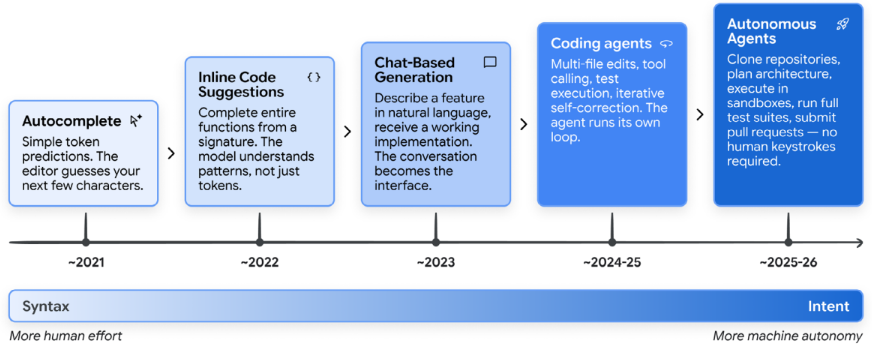


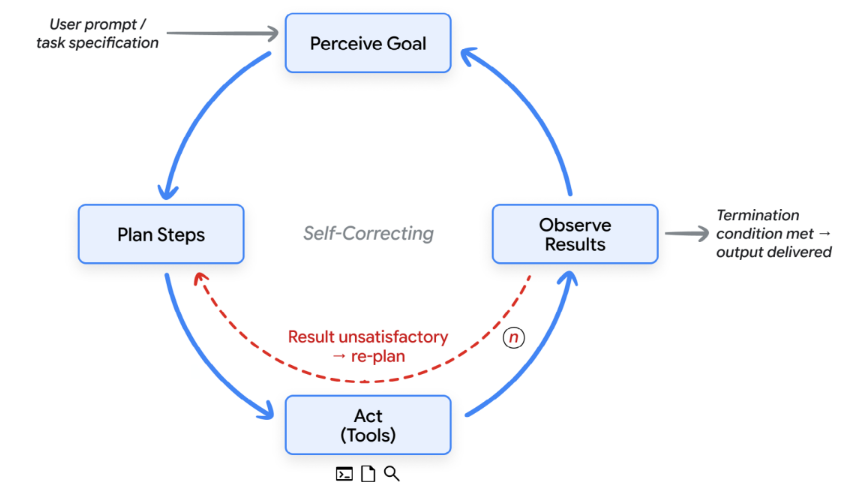

# Part 1: Prompting Claude — Simple to Complex

---

### Claude Model Family (2026) - Choose the right model!

| Model | ID | Context | Input $/1M | Output $/1M | Best For |
|---|---|---|---|---|---|
| Fable 5 | `claude-fable-5` | 1M | $10 | $50 | Frontier reasoning |
| **Opus 4.8** | `claude-opus-4-8` | 1M | $5 | $25 | **Default: complex research** |
| Sonnet 4.6 | `claude-sonnet-4-6` | 1M | $3 | $15 | Balanced speed/quality |
| Haiku 4.5 | `claude-haiku-4-5` | 200K | $1 | $5 | High-throughput classification |

> **Rule of thumb**: Start with Opus 4.8 for research. Use Haiku for batch classification tasks.

In [26]:
pip install Display -U -q


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Setup — run once per session
import anthropic
import os, json, pickle
from dotenv import load_dotenv

from IPython.display import display, Markdown

In [4]:
# If you are doing a production deployment at scale, get Anthropic API key
# it requires a separate paid account other than Claude Pro or Max
# Keep the API key in .env file and load it into the system environment
load_dotenv()

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")

In [6]:
# the API key looks like this:  sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
# I do NOT have. 

In [7]:
# initialize the client with the API key from environment variable
client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from environment

if client:
    display(Markdown("**Anthropic client initialized successfully.**"))
#print("Anthropic SDK version:", anthropic.__version__)

**Anthropic client initialized successfully.**

# Common issues of API call
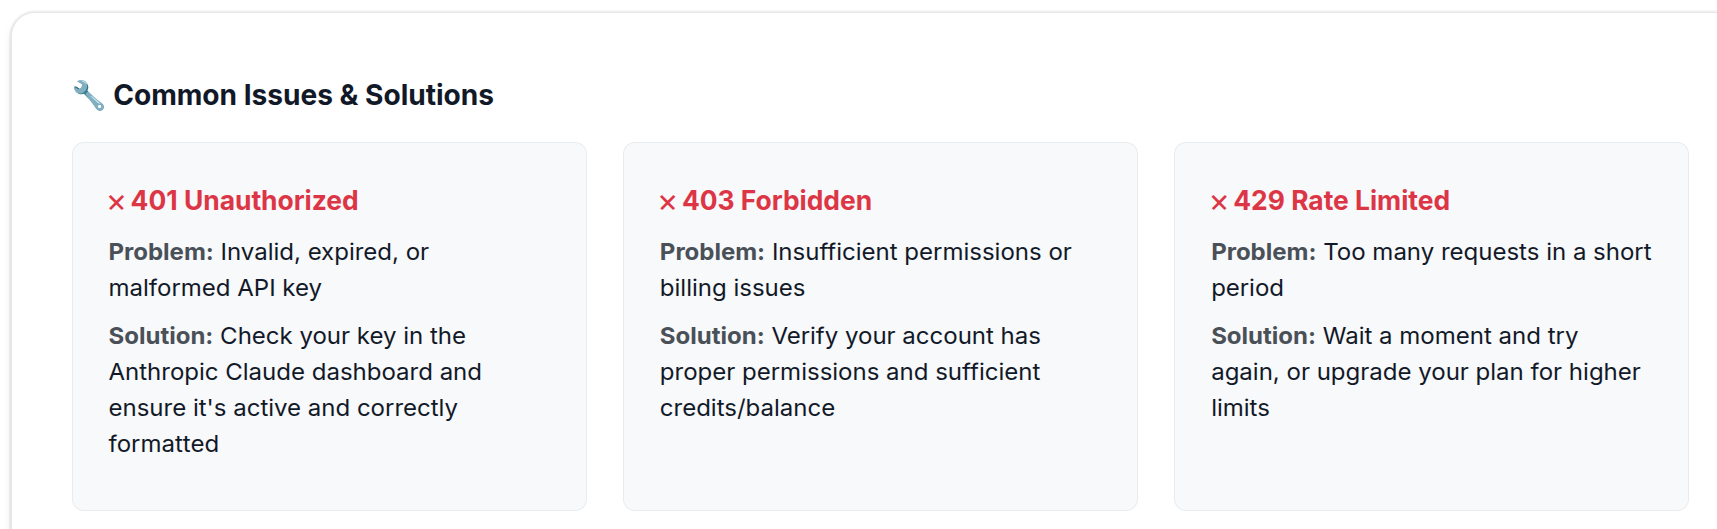

## 1.1 — The Simplest Possible Request

Three required fields:
- `model` — which Claude model
- `max_tokens` — output budget (not a target, a ceiling)
- `messages` — list of `{role, content}` dicts

```python
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=1024,
    messages=[{"role": "user", "content": "What is pharmacovigilance?"}],
    tools=[{"type": "memory_20250818", "name": "memory"}] #make API calls stateful, or have memory
)
print(response.content[0].text)
```

In [21]:
# # 1.1 — Simple one-shot call
# response = client.messages.create(
#     model="claude-opus-4-8",
#     max_tokens=512,
#     messages=[
#         {"role": "user", "content": "What is pharmacovigilance? Give a 2-sentence definition."}
#     ]
# )

# print(response.content[0].text)
# print(f"\n--- Token usage ---")
# print(f"Input:  {response.usage.input_tokens} tokens")
# print(f"Output: {response.usage.output_tokens} tokens")

# No API ? no problem ...
* select model - /model -> swith model -> choose Opus 
* just copy-n-paste the question "What is pharmacovigilance?" in Claude code chatbot 

## 1.2 — System Prompts: Setting Persona & Context

The `system` parameter sets persistent instructions Claude follows throughout the conversation.

**Good system prompts:**
- Define the AI's role and expertise
- Specify output format preferences
- Set domain constraints
- Establish tone and vocabulary

```python
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=1024,
    system="You are an expert pharmacovigilance scientist. Always cite MedDRA terminology.",
    messages=[{"role": "user", "content": "..."}]
)
```

In [14]:
display(Markdown('''Azithromycin's main cardiac adverse events, by MedDRA Preferred Term:

MedDRA PT	Mechanism	Risk Level
QT interval prolongation (PT: 10037142)	hERG potassium channel blockade	Most common; dose-dependent
Torsade de Pointes (PT: 10044243)	Secondary to QT prolongation	Rare but life-threatening
Ventricular tachycardia (PT: 10047281)	Triggered arrhythmia	Rare
Ventricular fibrillation (PT: 10047302)	Severe arrhythmia	Very rare
Cardiac arrest (PT: 10007515)	End-stage arrhythmia cascade	Very rare
Palpitations (PT: 10033557)	Electrophysiologic disturbance	Uncommon
MedDRA SOC: Cardiac disorders (10007541)

Key risk factors for cardiac ADRs:

Baseline QTc > 450ms
Concurrent QT-prolonging drugs (fluoroquinolones, antipsychotics, ondansetron)
Hypokalemia / hypomagnesemia
Elderly patients, female sex
Known structural heart disease
Regulatory context: FDA issued a Drug Safety Communication in 2013 warning about azithromycin's potential to cause abnormal heart rhythms, particularly fatal arrhythmias — leading to label updates across all formulations.'''))

Azithromycin's main cardiac adverse events, by MedDRA Preferred Term:

MedDRA PT	Mechanism	Risk Level
QT interval prolongation (PT: 10037142)	hERG potassium channel blockade	Most common; dose-dependent
Torsade de Pointes (PT: 10044243)	Secondary to QT prolongation	Rare but life-threatening
Ventricular tachycardia (PT: 10047281)	Triggered arrhythmia	Rare
Ventricular fibrillation (PT: 10047302)	Severe arrhythmia	Very rare
Cardiac arrest (PT: 10007515)	End-stage arrhythmia cascade	Very rare
Palpitations (PT: 10033557)	Electrophysiologic disturbance	Uncommon
MedDRA SOC: Cardiac disorders (10007541)

Key risk factors for cardiac ADRs:

Baseline QTc > 450ms
Concurrent QT-prolonging drugs (fluoroquinolones, antipsychotics, ondansetron)
Hypokalemia / hypomagnesemia
Elderly patients, female sex
Known structural heart disease
Regulatory context: FDA issued a Drug Safety Communication in 2013 warning about azithromycin's potential to cause abnormal heart rhythms, particularly fatal arrhythmias — leading to label updates across all formulations.

## 1.3 — Multi-Turn Conversations

Claude's API is **stateless** but claude code chatbot is not
 - to use API call, you have to send the full conversation history for next call, unlike Openclaw. 
 - Claude charges roundtrip, input and output tokens. 

```
Turn 1: [user_msg_1]                  → assistant_reply_1
Turn 2: [user_msg_1, reply_1, user_msg_2]  → assistant_reply_2
Turn 3: [user_msg_1, reply_1, ..., user_msg_3] → assistant_reply_3
```

**Key pattern:** Maintain a `history` list; append each exchange.

> **Cost insight:** Each turn re-sends the entire history. Use **prompt caching** to save up to 90% on repeated context (shown later).

In [19]:
# # 1.3 — Multi-turn conversation helper
# def chat(history, user_message, system=None, model="claude-opus-4-8", max_tokens=512):
#     """Send one turn; return (assistant_text, updated_history)."""
#     history = history + [{"role": "user", "content": user_message}]
#     kwargs = {"model": model, "max_tokens": max_tokens, "messages": history}
#     if system:
#         kwargs["system"] = system
#     response = client.messages.create(**kwargs)
#     reply = response.content[0].text
#     history = history + [{"role": "assistant", "content": reply}]
#     return reply, history

# # Simulate a multi-turn research conversation
# history = []

# reply, history = chat(history, "What MedDRA SOC covers cardiovascular adverse events?",
#                       system=PHARMACOVIGILANCE_SYSTEM)
# print("Turn 1:", reply[:200], "...\n")

# reply, history = chat(history, "List 5 important PT codes within that SOC.")
# print("Turn 2:", reply[:300], "...\n")

# reply, history = chat(history, "Which of those are most commonly reported in FAERS for statins?")
# print("Turn 3:", reply[:300])

# print(f"\nConversation turns: {len(history)//2}")

## 1.5 — Adaptive Thinking (Extended Reasoning)

Gives Claude a **private reasoning instruction** before responding.

| Setting | When to use |
|---|---|
| `effort: "low"` | Fast classification, simple extraction |
| `effort: "medium"` | Default — general reasoning tasks |
| `effort: "high"` | Complex multi-step reasoning |
| `effort: "xhigh"` | Hardest research questions, novel analysis |
| `effort: "max"` | Maximum reasoning (highest cost) |

**Key insight**: For complex question requiring multi-hop reasoning, use `effort: "high"` (default) or `"xhigh"`. Or use "low" (/fast in chatbot) 

In [ ]:
# 1.5 — Adaptive thinking with effort level
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=8000, #control token budget for reasoning depth
    thinking={"type": "adaptive", "display": "summarized"},
    output_config={"effort": "high"}, # control the depth of reasoning, default
    system=PHARMACOVIGILANCE_SYSTEM,
    messages=[{
        "role": "user",
        "content": """
        A patient is on metformin (T2DM), atorvastatin (dyslipidemia), and lisinopril (HTN).
        They report muscle weakness and dark urine.
        
        Reason through which drug(s) are most likely responsible, considering:
        1. Known ADR profiles of each drug
        2. Drug-drug interaction potential
        3. MedDRA PT codes for the reported symptoms
        4. Recommended next steps for the clinician
        """
    }]
)

# The response may include a thinking block followed by the answer
for block in response.content:
    if block.type == "thinking":
        # partially show the reasoning summary (first 500 characters) to avoid overwhelming output
        print("[REASONING SUMMARY]")
        print(block.thinking[:500] if block.thinking else "(omitted)")
        print()
    elif block.type == "text":
        # display the final answer text
        print("[ANSWER]")
        print(block.text)

## 1.6 — Tool Use

Claude can call your functions by describing them in JSON Schema.

**Two modes:**
1. **Manual loop** — you detect `tool_use` stop reason, call the function, send back `tool_result`
2. **SDK Tool Runner** — decorator-based, handles the loop automatically

```
Request → Claude decides to call tool → Your code executes function
         ← Send tool result back ←     → Claude continues with result
```

**Server-side tools** (no code needed on your end):
- `web_search` — real-time web search
- `code_execution` — Python sandbox
- `computer_use` — desktop automation

In [29]:
from IPython.display import display, Markdown

display(Markdown("""
```mermaid
flowchart LR
    A([Request]) --> B[Claude decides\\nto call tool]
    B --> C[Your code\\nexecutes function]
    C --> D[Send tool\\nresult back]
    D --> E{Claude continues}
    E -->|another tool call| B
    E -->|done| F([Final Response])
```
"""))


```mermaid
flowchart LR
    A([Request]) --> B[Claude decides\nto call tool]
    B --> C[Your code\nexecutes function]
    C --> D[Send tool\nresult back]
    D --> E{Claude continues}
    E -->|another tool call| B
    E -->|done| F([Final Response])
```


### 1.6a — Manual tool use loop, 
 - Using the OpenFDA API — free, no key needed, returns real FAERS data

In [40]:
import json, requests
from types import SimpleNamespace
from utils.func import get_faers_count

# --- 1. define tool ---
tools = [{
    "name": "get_faers_count",
    "description": "Look up real FAERS adverse event report count for a drug via OpenFDA",
    "input_schema": {
        "type": "object",
        "properties": {
            "drug": {"type": "string", "description": "Drug name, e.g. metformin"}
        },
        "required": ["drug"]
    }
}]

# --- 2. simulate the Claude response that requests a tool call ---
tool_block = SimpleNamespace(
    type="tool_use",
    id="tool_use_demo_001",
    name="get_faers_count",
    input={"drug": "semaglutide"}
)
response = SimpleNamespace(
    stop_reason="tool_use",
    content=[tool_block]
)

# --- 3. tool dispatch (identical to real loop)
tool   = next(b for b in response.content if b.type == "tool_use")
result = get_faers_count(**tool.input)          # hits real OpenFDA
print(f"[tool] {tool.input} → {result}")

messages = []
messages.append({"role": "assistant", "content": response.content})
messages.append({
    "role": "user",
    "content": [{
        "type": "tool_result",
        "tool_use_id": tool.id,
        "content": json.dumps(result)
    }]
})

print("\nmessages ready to send back to Claude:")
print(json.dumps(messages, indent=2, default=str))

[tool] {'drug': 'semaglutide'} → {'drug': 'semaglutide', 'faers_reports': 6618}

messages ready to send back to Claude:
[
  {
    "role": "assistant",
    "content": [
      "namespace(type='tool_use', id='tool_use_demo_001', name='get_faers_count', input={'drug': 'semaglutide'})"
    ]
  },
  {
    "role": "user",
    "content": [
      {
        "type": "tool_result",
        "tool_use_id": "tool_use_demo_001",
        "content": "{\"drug\": \"semaglutide\", \"faers_reports\": 6618}"
      }
    ]
  }
]


## 1.7 — Structured Outputs (JSON Schema)

Force Claude to return valid, schema-conforming JSON — ideal for:
- Extracting entities from clinical text
- Building downstream data pipelines
- Classification with confidence scores

Two approaches:
1. **`output_config.format`** — built-in schema enforcement
2. **`client.messages.parse()`** — validates + auto-parses response

> No more regex hacks on JSON output!

In [42]:
# 1.7 — Structured output: extract drug query information from FAERS DB
from IPython.display import display, Markdown

for msg in messages:
    role = msg["role"].upper()
    content = msg["content"]

    if isinstance(content, list):
        for block in content:
            if hasattr(block, "type"):                        # SimpleNamespace block
                display(Markdown(f"**[{role} · {block.type}]** `id={block.id}`  \ninput: `{block.input}`"))
            elif isinstance(block, dict):                     # tool_result dict
                display(Markdown(f"**[{role} · tool_result]** `id={block['tool_use_id']}`  \n```json\n{block['content']}\n```"))
    else:
        display(Markdown(f"**[{role}]** {content}"))

**[ASSISTANT · tool_use]** `id=tool_use_demo_001`  
input: `{'drug': 'semaglutide'}`

**[USER · tool_result]** `id=tool_use_demo_001`  
```json
{"drug": "semaglutide", "faers_reports": 6618}
```

## 1.8 use claude **prefix** and **postfix** 
* generate interactive App or dashboard, e.g. describe the transformer algorithm **artifact**
* deep reasoning (level 99 expert mode) e.g. `describe the transformer algorithm **L99**
* decisive god mode e.g `**godmode** describe the transformer algorithm  

### 1.8a - prompt: "describe the transformer algorithm **artifact**"

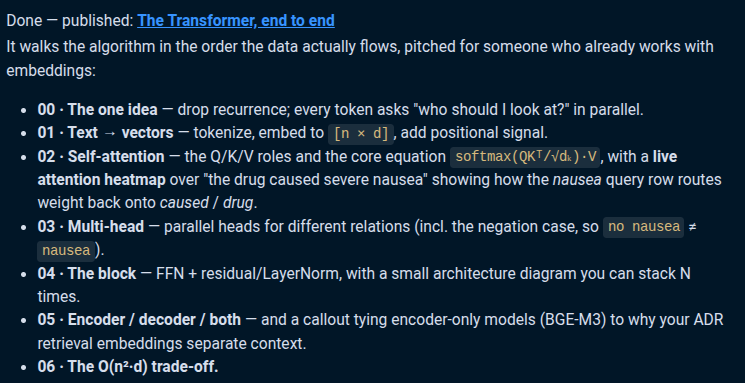

In [ ]:
https://claude.ai/code/artifact/7e5053fe-f66a-4d5c-bb2f-b3caec2a7b07

### 1.8b - prompt: "L99 describe the transformer algorithm" 

The core idea
Older sequence models (RNNs/LSTMs) read tokens one at a time, carrying a running memory forward — sequential and forgetful over long distances. The transformer drops recurrence entirely. Instead, every token looks at every other token simultaneously and decides how much to borrow from each. That routing operation is attention, and the rest of the architecture just supports it.

The pipeline
1. Text → vectors

Tokenize into sub-words (hepatotoxicity → hepato·toxic·ity).
Embed each token id into a learned vector of dimension d (1024 for BGE-M3). Sequence becomes a matrix [n × d].
Add positional encoding (sinusoidal, or learned/rotary) — attention is order-blind on its own, so position must be injected.
2. Self-attention (the engine)

Each token vector is projected three ways via learned matrices:

Query (Q) — what this token is looking for
Key (K) — what this token offers to others
Value (V) — the content passed along if attended to
A token's new representation is a weighted average of all values, where weights come from how well its query matches each key (a dot product), scaled and softmax-normalized so they sum to 1:

$$\text{Attention}(Q,K,V) = \text{softmax}!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The √dₖ scaling keeps the dot products from growing large and saturating the softmax (which would kill gradients). That single line is the whole mechanism — e.g. the query for nausea in "drug caused nausea" lands most of its weight on caused and drug.

3. Multi-head attention

One attention pattern captures one kind of relationship. So Q/K/V are split into h parallel heads (e.g. 8–16), each with its own smaller projections and its own attention map — one head may track syntax, another negation (critical so no nausea ≠ nausea). Outputs are concatenated and projected back to d.

4. The rest of the block

Attention mixes information across tokens; two more pieces finish the block, each wrapped in a residual connection (add the input back) + layer normalization so very deep stacks train stably:

Feed-forward network (FFN) — a small 2-layer MLP applied to each token independently; this processes what attention gathered and holds much of the model's stored knowledge.
Add & Norm — x = LayerNorm(x + Sublayer(x)) after both attention and the FFN.
5. Stack it. One block feeds the next — BERT-base has 12, BGE-M3 has 24, large LLMs have 80+.

Three flavors
Encoder-only (BERT, BGE-M3): bidirectional; every token sees every other. Pool the per-token outputs (mean or [CLS]) into one vector → exactly your ADR retrieval embeddings.
Decoder-only (GPT/Claude-style): causal mask, each token sees only earlier ones → generation.
Encoder–decoder (T5): encoder reads source, decoder attends to both → sequence-to-sequence.
The trade-off
Full self-attention compares every token with every other, so cost is O(n²·d) in time and memory — the price of global context, and the reason long-context research is mostly about taming that quadratic (sparse / sliding-window / linear attention). In return: full parallelism across positions and a direct path between any two tokens regardless of distance.

Why it matters for your pipeline: because attention has already fused context before pooling, nausea in "drug caused nausea" vs. "no nausea reported" occupy different regions of the embedding space — which is what makes semantic retrieval over FAERS work at all.

Want me to connect this specifically to how Claude (decoder-only) differs from your BGE-M3 encoder for the Yale audience?

---
# Part 2: VS Code Extension & Claude Code CLI

## What is Claude Code?

An **AI coding assistant** that lives in your terminal and IDE — it reads your entire codebase and acts on it.

### Installation
```bash
# Install globally via npm
npm install -g @anthropic-ai/claude-code

# VS Code: search "Claude Code" in Extensions marketplace
# Then authenticate:
claude auth
```

### Key Principle
Claude Code is an **agent** — it can read files, run shell commands, write code, and iterate. You describe *what* you want; it figures out *how*.

## 2.1 — Core CLI Features

### Interactive Mode (default)
```bash
cd ~/Barn/GQ/ADR
claude                              # Start interactive session
```

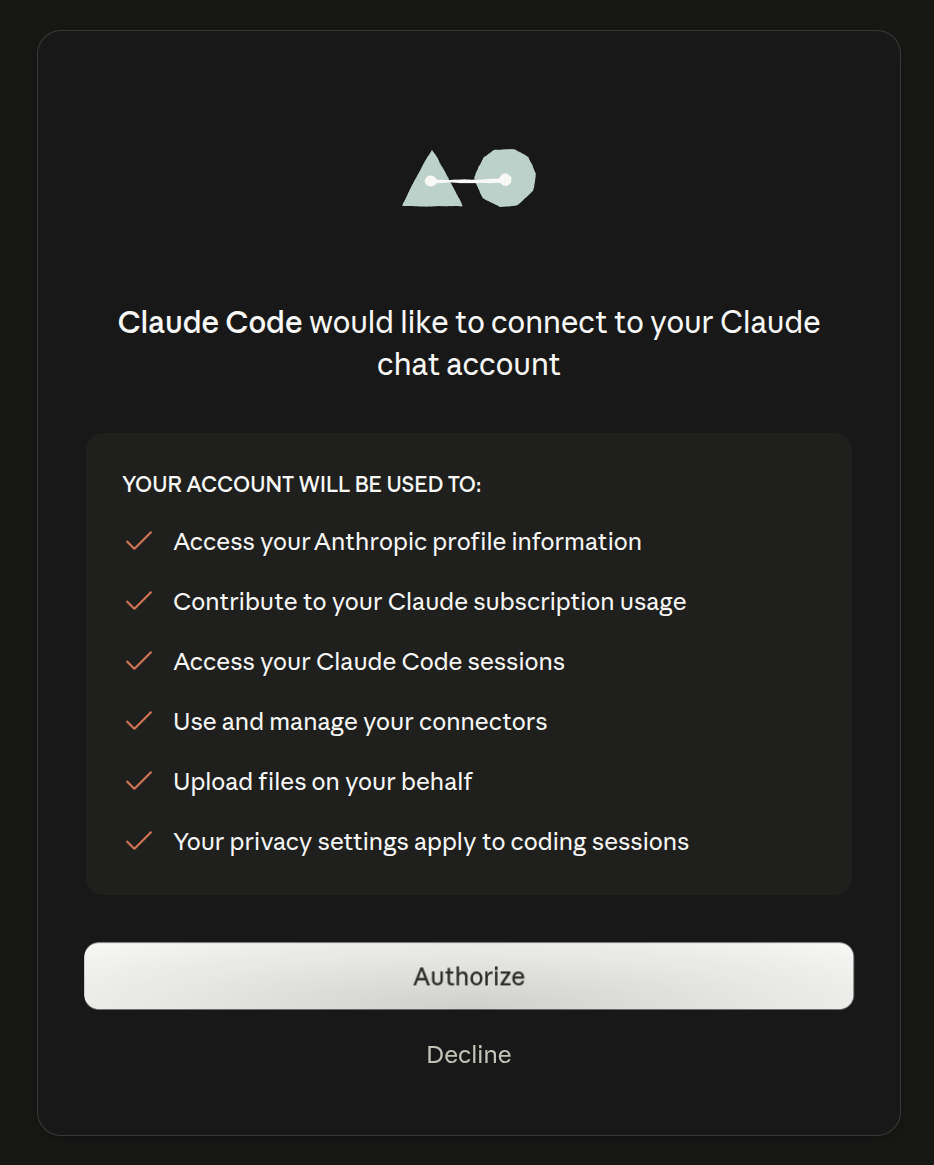

### One-shot Commands
```bash
claude "Explain what FAERS_Prep.ipynb does"          # Non-interactive
```
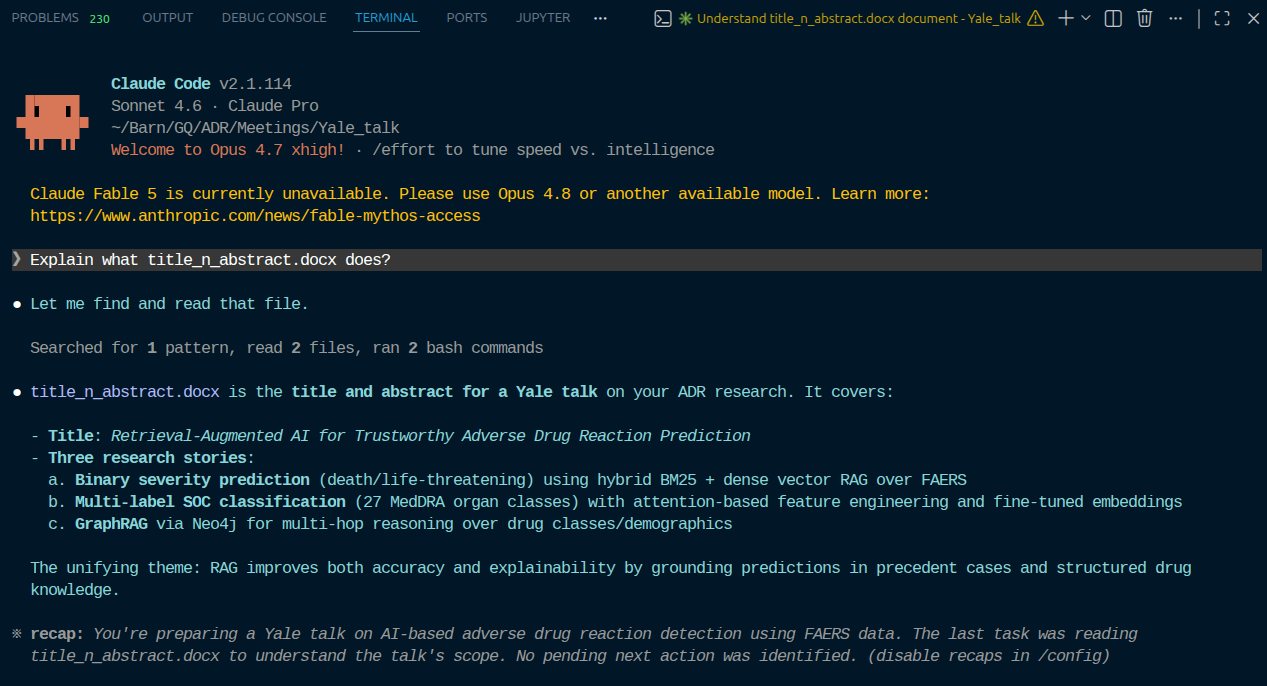

```bash
claude -p "Review this Python file" --file utils.py  # With file context
```



### Piping
```bash
cat adr_detection.py | claude "Find potential bugs"
git diff | claude "Write a commit message"
```

## 2.2 — Slash Commands Reference

| Command | What it does |
|---|---|
| `/help` | Show all available commands |
| `/clear` | Reset conversation context |
| `/compact` | Summarize and compress conversation |
| `/cost` | Show token usage and cost |
| `/model` | Switch models mid-session |
| `/fast` | Toggle Fast mode (Opus with faster output) |
| `/plan` | Enter planning mode — Claude presents a plan first |
| `/review` | Review code changes |
| `/mcp` | Manage MCP server connections |
| `/add-dir` | Add a directory to Claude's context |

### For Jupyter Research Workflows
```
/plan  → Review the plan before Claude touches any code
/cost  → Track API spending per session
/compact → Keep long research sessions alive without losing context
```

## 2.3 — VS Code Extension Workflow

### The Difference from GitHub Copilot

| Feature | GitHub Copilot | Claude Code |
|---|---|---|
| Scope | Current file | Entire repo |
| Tool use | Code completion only | Reads, writes, runs terminal |
| Context | Line-level | Project-level |
| Interaction | Inline completions | Conversational agent |

### Common VS Code Workflows
1. **Debug a failing test**: Open test output → ask Claude what's wrong
2. **Refactor a module**: "Refactor *your_code.py* to use pandas 2.0 API"
3. **Write documentation**: Select a function → "Document this with a docstring"
4. **Understand legacy code**: "Explain what this embedding pipeline does"
5. **Generate unit tests**: "Write pytest tests for the lookup_faers_reports function"

## 2.4 — MCP: Model Context Protocol

MCP lets Claude connect to **external data sources and tools** via a standard protocol.

### Configure `.mcp.json` in project path 
```json
{
  "mcpServers": {
    "faers_query": {
      "command": "/home/dada/anaconda3/bin/python",
      "args": ["/home/dada/Barn/GQ/ADR/Meetings/Yale_talk/utils/mcp_faers_server.py"]
    }
  }
}
```

Once connected, Claude can query FAERS query directly during a conversation — without any copy-paste!

### **utils/mcp_faers_server.py** — 3 tools for MCP server:
|Tool |OpenFDA call	| Use case|
|------|----------|---------|
|get_faers_count(drug)	|Total reports for a drug	|Quick signal triage|
|get_faers_top_events(drug, top_n)	|Top MedDRA PTs for a drug	|Adverse event profiling|
|get_faers_drug_event_pair(drug, event_pt)	|Co-report count	|PRR/ROR numerator|

###  use **Control+Shift+p** -> type "Developer: Reload Window" to refresh the notebook and see the cache in action.

### run **/mcp** in Claude chat
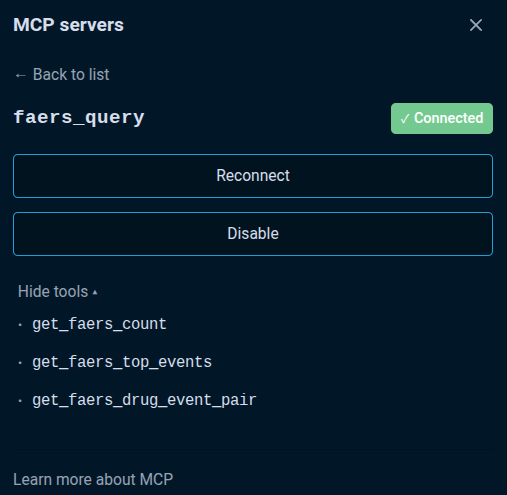

### run a test on MCP server tool in Claude chat
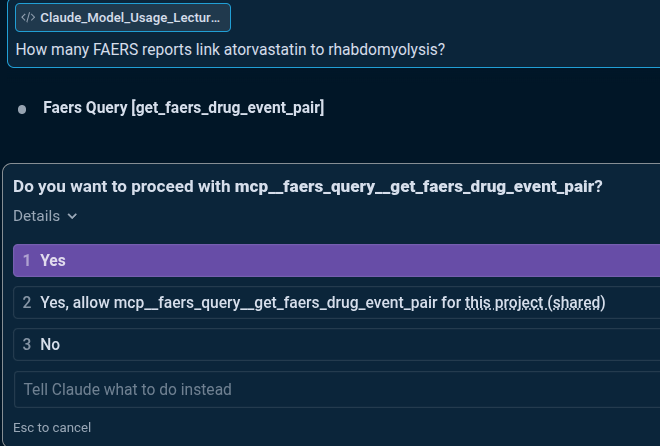




```
4,215 FAERS reports link atorvastatin to rhabdomyolysis.

This is the PRR/ROR numerator (a cell in the 2×2 table). To compute the full signal:

PRR = (4215 / total_atorvastatin_reports) ÷ (all_rhabdomyolysis_reports / all_reports)
Use get_faers_count("atorvastatin") for the denominator and a separate OpenFDA count query for background rhabdomyolysis rate
Want me to pull those numbers and compute the PRR?
```

### 2.5 Install External MCP Server 
* open claude in terminal 
* go to the project root path, e.g.   
* run installation cli
   - **claude mcp add playwright npx @playwright/mcp@latest** (MS playwright)
   - **claude mcp add --transport http googledrive-composio** (google drive/workspace)
* double check the **.mcp.json** to check if the MCP configuration file (.json) is updated with new MCP server
* reload claude code by **Control+Shift+p**: Developer: Reload Windows

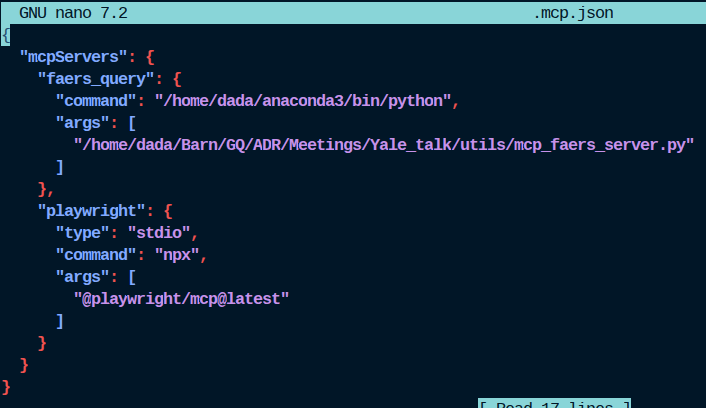

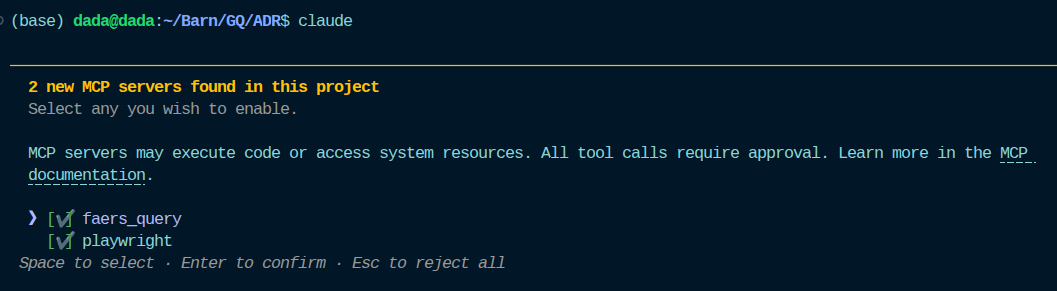

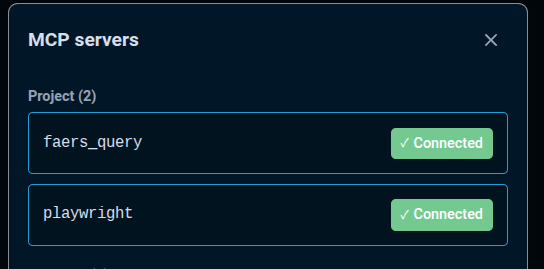

## 2.6 AI Scientist - Claude ToolUniverse Plugin
* 1. Register the ToolUniverse marketplace from GitHub
  - claude plugin marketplace add mims-harvard/ToolUniverse

* 2. Install the plugin
  - claude plugin install tooluniverse@tooluniverse
  
* 3. Ref: https://zitniklab.hms.harvard.edu/ToolUniverse/guide/building_ai_scientists/claude_code.html

## Resources & References

| Resource | URL |
|---|---|
| Anthropic API Docs | https://docs.anthropic.com |
| Python SDK | https://github.com/anthropic-ai/anthropic-sdk-python |
| Claude Code CLI | https://claude.ai/code |
| Model Pricing | https://anthropic.com/api/pricing |
| MedDRA Browser | https://www.meddra.org |
| FAERS Data | https://fis.fda.gov/extensions/FPD-QDE-FAERS |

### Install for this lecture
```bash
pip install anthropic>=0.40.0
npm install -g @anthropic-ai/claude-code
export ANTHROPIC_API_KEY="sk-ant-..."
```